Imports

In [20]:
import os
import glob
import json
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Conv1D, MaxPooling1D, Masking, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Globbing and Label Mapping

In [ ]:
# 1. Gather all file paths
DATA_PATH = '/home/dl/tf_project/Sign-Language-Interpreter/data'
file_paths = glob.glob(os.path.join(DATA_PATH, '*', '*.npy'))

# 2. Extract labels from folder names
labels = [os.path.basename(os.path.dirname(f)) for f in file_paths]

# 3. Create and Save Label Map (Crucial for Inference later)
unique_actions = sorted(list(set(labels)))
label_map = {label: num for num, label in enumerate(unique_actions)}

with open('label_map.json', 'w') as f:
    json.dump(label_map, f)

# 4. Convert labels to integers
y = [label_map[label] for label in labels]

# 5. Split Data (80/20)
# Use stratify to ensure each word is equally represented in both sets
X_train_files, X_val_files, y_train, y_val = train_test_split(
    file_paths, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Setup complete. Training on {len(X_train_files)} samples, validating on {len(X_val_files)}.")

Setup complete. Training on 6321 samples, validating on 1581.


Data Generator (Sequence Generator)

In [22]:
class SignLanguageGenerator(Sequence):
    def __init__(self, file_paths, labels, batch_size=32, seq_len=30):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.seq_len = seq_len

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_x_paths = self.file_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        X_batch = []
        for path in batch_x_paths:
            data = np.load(path) # Shape: (Frames, 126)
            
            # --- NORMALIZATION (Wrist Centering) ---
            for f in range(len(data)):
                # Left Hand relative to LH Wrist (0,1,2)
                data[f, 0:63] -= np.tile(data[f, 0:3], 21)
                # Right Hand relative to RH Wrist (63,64,65)
                data[f, 63:126] -= np.tile(data[f, 63:66], 21)
            
            # --- TEMPORAL STANDARDIZATION ---
            if len(data) > self.seq_len:
                data = data[:self.seq_len]
            else:
                data = np.pad(data, ((0, self.seq_len - len(data)), (0, 0)), mode='constant')
            
            X_batch.append(data)
            
        return np.array(X_batch), np.array(batch_y)

CRNN Architecture

In [ ]:
model = Sequential([
    Input(shape=(30, 126)),
    Masking(mask_value=0.0), # Ignore padded zeros
    
    # Spatial Feature Extractor
    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),
    
    # Temporal Feature Extractor
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(64)),
    
    # Classification Head
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(unique_actions), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/home/suraj_rk/dl/tf_project/Sign-Language-Interpreter/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Training

In [24]:
# Create Generators
train_gen = SignLanguageGenerator(X_train_files, y_train)
val_gen = SignLanguageGenerator(X_val_files, y_val)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

# Fit
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1 
)

Epoch 1/100


/home/suraj_rk/dl/tf_project/Sign-Language-Interpreter/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1775895886.528483   32230 cuda_dnn.cc:529] Loaded cuDNN version 91900


198/198 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.1973 - loss: 2.4720 - val_accuracy: 0.4156 - val_loss: 1.8336 - learning_rate: 0.0010
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.3811 - loss: 1.8413 - val_accuracy: 0.5092 - val_loss: 1.6049 - learning_rate: 0.0010
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4901 - loss: 1.5893 - val_accuracy: 0.5661 - val_loss: 1.4388 - learning_rate: 0.0010
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5570 - loss: 1.4352 - val_accuracy: 0.5319 - val_loss: 1.4695 - learning_rate: 0.0010
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5955 - loss: 1.3075 - val_accuracy: 0.6445 - val_loss: 1.1901 - learning_rate: 0.0010
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6355 - loss: 1.1959 - val_accuracy: 0.6490 - val_loss: 1.1774 - learning_rate: 0.0010
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6645 - loss: 1.1212

Evaluation

Calculating predictions for validation set...
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

Per-Word Evaluation Report:
              precision    recall  f1-score   support

       drink       0.85      0.85      0.85        80
        food       0.86      0.82      0.84        79
          go       0.69      0.56      0.62        78
        have       0.77      0.87      0.82        67
       hello       0.86      0.92      0.89        78
     hesheit       0.68      0.75      0.72        72
        home       0.82      0.76      0.79        79
      hungry       0.83      0.75      0.79        77
      minemy       0.65      0.52      0.58        75
          no       0.83      0.80      0.81        74
         now       0.86      0.88      0.87        74
      please       0.61      0.66      0.64        77
       sleep       0.78      0.75      0.77        76
        stay       0.83      0.87      0.85        75
       store       0.57      0.67      0.61        75
    thankyou       0

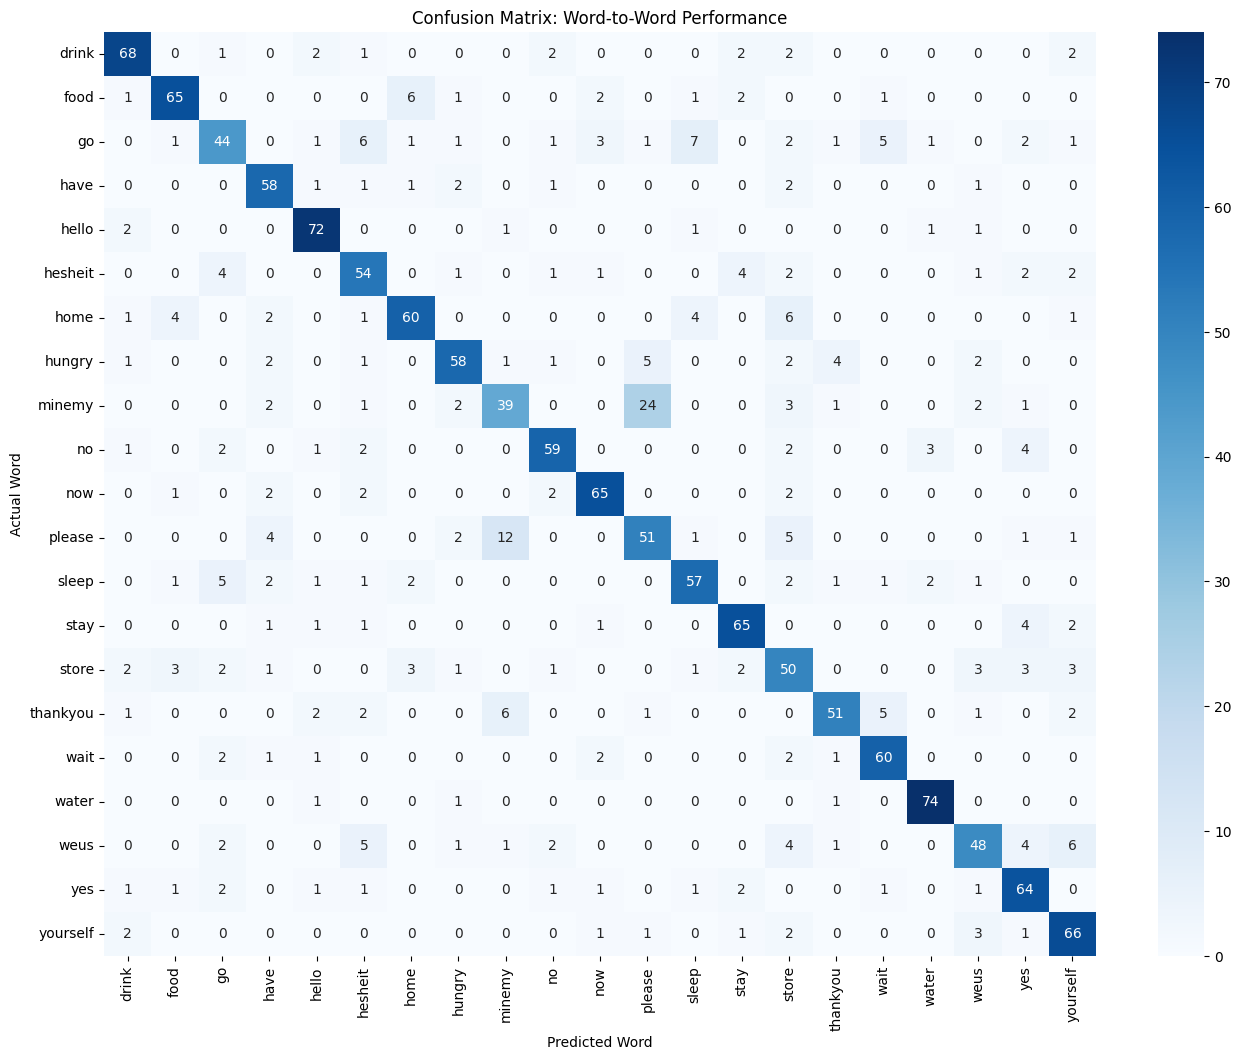

In [26]:
# 1. Get Predictions
print("Calculating predictions for validation set...")
# Ensure shuffle=False in your validation generator for this part!
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get True Labels from the generator
y_true = []
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true.extend(labels)
y_true = np.array(y_true)

# 3. Print Per-Word Accuracy (Classification Report)
# This gives you Precision, Recall, and F1-Score for EVERY word
report = classification_report(y_true, y_pred, target_names=unique_actions)
print("\nPer-Word Evaluation Report:")
print(report)

# 4. Visualize with a Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_actions, 
            yticklabels=unique_actions)
plt.title('Confusion Matrix: Word-to-Word Performance')
plt.xlabel('Predicted Word')
plt.ylabel('Actual Word')
plt.show()

Save Model

In [27]:
model.save('sign_language_crnn.h5')
print("Model saved as sign_language_crnn.h5")

Model saved as sign_language_crnn.h5
